# AuraFitness Data Cleaning Analysis

This notebook cleans the real exercise datasets selected for the AuraFitness MVP.

Input datasets:

1. `fitness_exercises/exercises.csv`
2. `gym_exercises/Gym Exercises Dataset.xlsx`

Output:

- `ai/datasets/processed/exercises_clean.csv`
- `ai/reports/exercise_cleaning_report.csv`
- cleaning charts in `ai/reports/figures/`

Rules:

- No fake exercise records
- No sample training data
- Missing real values are marked as `unknown`
- Cleaning decisions must be visible and reproducible

## 1. Import libraries and prepare paths

This cell imports the required Python libraries and sets the correct project path.

It also makes sure the notebook can import scripts from the `ai/` project folder.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

AI_ROOT = Path.cwd()

if AI_ROOT.name == "notebooks":
    AI_ROOT = AI_ROOT.parent

if str(AI_ROOT) not in sys.path:
    sys.path.append(str(AI_ROOT))

RAW_DATA_DIR = AI_ROOT / "datasets" / "raw"
PROCESSED_DATA_DIR = AI_ROOT / "datasets" / "processed"
REPORTS_DIR = AI_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("AI root:", AI_ROOT)
print("Raw data:", RAW_DATA_DIR)
print("Processed data:", PROCESSED_DATA_DIR)
print("Figures:", FIGURES_DIR)

AI root: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai
Raw data: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\datasets\raw
Processed data: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\datasets\processed
Figures: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures


## 2. Load the real raw exercise datasets

This cell loads the two real exercise datasets from `ai/datasets/raw/`.

If the files are missing, the notebook should stop instead of creating fake data.

In [2]:
fitness_file = RAW_DATA_DIR / "fitness_exercises" / "exercises.csv"
gym_file = RAW_DATA_DIR / "gym_exercises" / "Gym Exercises Dataset.xlsx"

if not fitness_file.exists():
    raise FileNotFoundError(f"Missing file: {fitness_file}")

if not gym_file.exists():
    raise FileNotFoundError(f"Missing file: {gym_file}")

fitness_raw_df = pd.read_csv(fitness_file)
gym_raw_df = pd.read_excel(gym_file)

print("Fitness dataset shape:", fitness_raw_df.shape)
print("Gym dataset shape:", gym_raw_df.shape)

Fitness dataset shape: (1324, 23)
Gym dataset shape: (471, 10)


## 3. Inspect raw columns

This cell shows the real column names from both datasets.

This is important because we must map different source column names into one clean AuraFitness schema.

In [3]:
print("Fitness dataset columns:")
print(fitness_raw_df.columns.tolist())

print("\nGym dataset columns:")
print(gym_raw_df.columns.tolist())

display(fitness_raw_df.head())
display(gym_raw_df.head())

Fitness dataset columns:
['bodyPart', 'equipment', 'gifUrl', 'id', 'name', 'target', 'secondaryMuscles/0', 'secondaryMuscles/1', 'instructions/0', 'instructions/1', 'instructions/2', 'instructions/3', 'instructions/4', 'instructions/5', 'secondaryMuscles/2', 'instructions/6', 'instructions/7', 'secondaryMuscles/3', 'instructions/8', 'secondaryMuscles/4', 'instructions/9', 'secondaryMuscles/5', 'instructions/10']

Gym dataset columns:
['Exercise_Name', 'Description_URL', 'Exercise_Image', 'Exercise_Image1', 'muscle_gp_details', 'muscle_gp', 'equipment_details', 'Equipment', 'Rating', 'Description']


,bodyPart,equipment,gifUrl,id,name,target,secondaryMuscles/0,secondaryMuscles/1,instructions/0,instructions/1,...,instructions/5,secondaryMuscles/2,instructions/6,instructions/7,secondaryMuscles/3,instructions/8,secondaryMuscles/4,instructions/9,secondaryMuscles/5,instructions/10
0,waist,body weight,https://v2.exercisedb.io/image/MOnK4iG0MEt9h8,1,3/4 sit-up,abs,hip flexors,lower back,Lie flat on your back with your knees bent and...,Place your hands behind your head with your el...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,waist,body weight,https://v2.exercisedb.io/image/PERWLDGUxVbpHS,2,45° side bend,abs,obliques,NaN,Stand with your feet shoulder-width apart and ...,Keeping your back straight and your core engag...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,waist,body weight,https://v2.exercisedb.io/image/PLr4yo3j-f1amp,3,air bike,abs,hip flexors,NaN,Lie flat on your back with your hands placed b...,Lift your legs off the ground and bend your kn...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,upper legs,body weight,https://v2.exercisedb.io/image/XPQwM7HECjgNFE,1512,all fours squad stretch,quads,hamstrings,glutes,Start on all fours with your hands directly un...,"Extend one leg straight back, keeping your kne...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,waist,body weight,https://v2.exercisedb.io/image/5nYph4eUGNiEdf,6,alternate heel touchers,abs,obliques,NaN,Lie flat on your back with your knees bent and...,"Extend your arms straight out to the sides, pa...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Exercise_Name,Description_URL,Exercise_Image,Exercise_Image1,muscle_gp_details,muscle_gp,equipment_details,Equipment,Rating,Description
0,Rickshaw Carry,https://www.bodybuilding.com/exercises/ricksha...,https://www.bodybuilding.com/exercises/exercis...,https://www.bodybuilding.com/exercises/exercis...,https://www.bodybuilding.com/exercises/muscle/...,Forearms,https://www.bodybuilding.com/exercises/equipme...,Other,9.6,Average
1,Single-Leg Press,https://www.bodybuilding.com/exercises/single-...,https://www.bodybuilding.com/images/2020/xdb/c...,https://www.bodybuilding.com/images/2020/xdb/c...,https://www.bodybuilding.com/exercises/muscle/...,Quadriceps,https://www.bodybuilding.com/exercises/equipme...,Machine,9.6,Average
2,Landmine twist,https://www.bodybuilding.com/exercises/landmin...,https://www.bodybuilding.com/images/2020/xdb/c...,https://www.bodybuilding.com/images/2020/xdb/c...,https://www.bodybuilding.com/exercises/muscle/...,Abdominals,https://www.bodybuilding.com/exercises/equipme...,Other,9.5,Average
3,Weighted pull-up,https://www.bodybuilding.com/exercises/weighte...,https://www.bodybuilding.com/images/2020/xdb/c...,https://www.bodybuilding.com/images/2020/xdb/c...,https://www.bodybuilding.com/exercises/muscle/...,Lats,https://www.bodybuilding.com/exercises/equipme...,Other,9.5,Average
4,T-Bar Row with Handle,https://www.bodybuilding.com/exercises/t-bar-r...,https://www.bodybuilding.com/exercises/exercis...,https://www.bodybuilding.com/images/2020/octob...,https://www.bodybuilding.com/exercises/muscle/...,Middle Back,https://www.bodybuilding.com/exercises/equipme...,Other,9.5,Average


## 4. Run the reusable cleaning pipeline

This cell imports the cleaning pipeline from `scripts/clean_data.py`.

The same cleaning logic can be run from both notebook and terminal.

In [4]:
from scripts.clean_data import clean_all_exercise_data

cleaned_df = clean_all_exercise_data()

print("Cleaned dataset shape:", cleaned_df.shape)
display(cleaned_df.head())

Fitness exercises shape: (1324, 9)
Gym exercises shape: (471, 9)
Merged shape: (1795, 9)
Rows before dedupe: 1795
Rows after dedupe: 1730
Removed duplicates: 65


Saved clean dataset: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\datasets\processed\exercises_clean.csv
Saved cleaning report: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\exercise_cleaning_report.csv
Cleaned dataset shape: (1730, 10)


,exercise_id,name,body_part,target_muscle,secondary_muscles,equipment,exercise_type,difficulty_level,instructions,source_dataset
0,ex_0e2eff7dc4,3/4 sit-up,abdominals,abdominals,unknown,bodyweight,strength,unknown,unknown,gym_exercises
1,ex_a66a59d23a,Ab Roller,abdominals,abdominals,unknown,other,strength,unknown,unknown,gym_exercises
2,ex_b1ced5f64e,Ab bicycle,abdominals,abdominals,unknown,bodyweight,strength,unknown,unknown,gym_exercises
3,ex_32a5b22d7e,Barbell Ab Rollout - On Knees,abdominals,abdominals,unknown,barbell,strength,unknown,unknown,gym_exercises
4,ex_3f76f9aa3b,Barbell roll-out,abdominals,abdominals,unknown,barbell,strength,unknown,unknown,gym_exercises


## 5. Validate the final schema

This cell checks whether the cleaned dataset contains the exact columns required by the AuraFitness app and AI engines.

In [5]:
expected_columns = [
    "exercise_id",
    "name",
    "body_part",
    "target_muscle",
    "secondary_muscles",
    "equipment",
    "exercise_type",
    "difficulty_level",
    "instructions",
    "source_dataset",
]

missing_columns = [column for column in expected_columns if column not in cleaned_df.columns]

if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

print("Schema validation passed.")
print(cleaned_df.columns.tolist())

Schema validation passed.
['exercise_id', 'name', 'body_part', 'target_muscle', 'secondary_muscles', 'equipment', 'exercise_type', 'difficulty_level', 'instructions', 'source_dataset']


## 6. Check missing or unknown values

This cell checks how many values are marked as `unknown`.

This helps us understand where the real datasets are incomplete.

In [6]:
unknown_summary = []

for column in cleaned_df.columns:
    unknown_count = int((cleaned_df[column].astype(str).str.lower() == "unknown").sum())
    unknown_summary.append({
        "column": column,
        "unknown_count": unknown_count,
        "unknown_percentage": round((unknown_count / len(cleaned_df)) * 100, 2)
    })

unknown_df = pd.DataFrame(unknown_summary)
display(unknown_df)

,column,unknown_count,unknown_percentage
0,exercise_id,0,0.00
1,name,0,0.00
2,body_part,0,0.00
3,target_muscle,0,0.00
4,secondary_muscles,412,23.82
5,equipment,17,0.98
6,exercise_type,0,0.00
7,difficulty_level,1730,100.00
8,instructions,412,23.82
9,source_dataset,0,0.00


## 7. Chart unknown values by column

This chart shows which fields are weak or incomplete after cleaning.

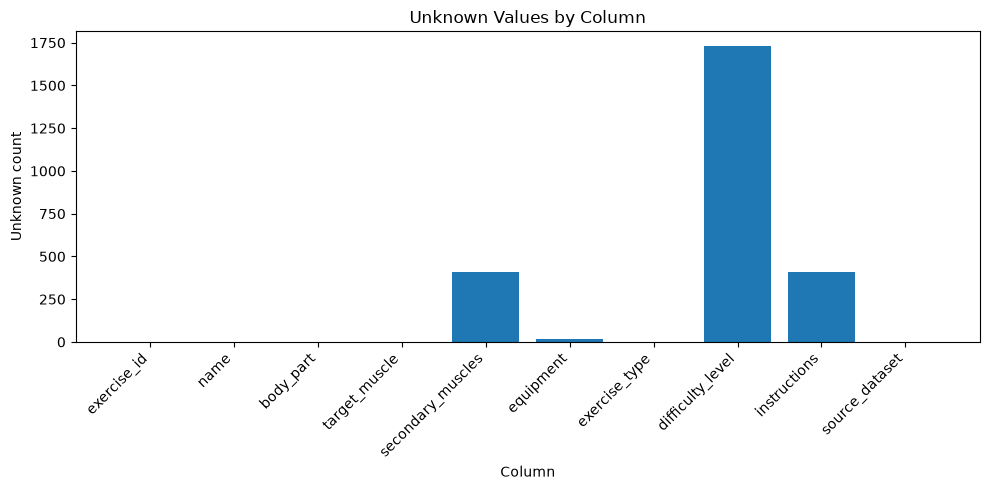

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\exercise_cleaning_unknown_values.png


In [7]:
plt.figure(figsize=(10, 5))
plt.bar(unknown_df["column"], unknown_df["unknown_count"])
plt.title("Unknown Values by Column")
plt.xlabel("Column")
plt.ylabel("Unknown count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

output_path = FIGURES_DIR / "exercise_cleaning_unknown_values.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## 8. Chart exercise count by body part

This chart shows the distribution of exercises by body part.

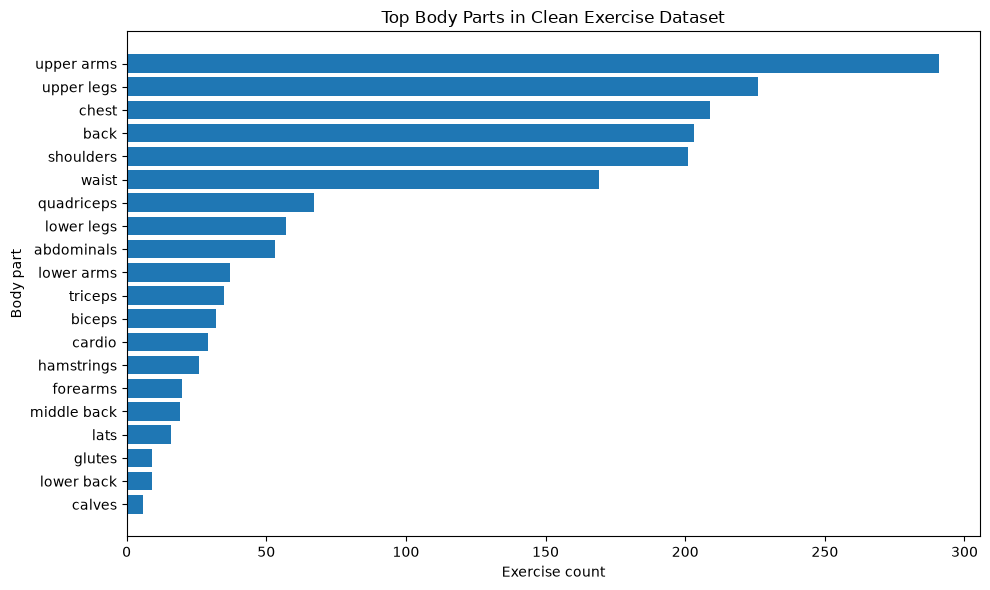

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\exercise_cleaning_body_parts.png


In [8]:
body_part_counts = cleaned_df["body_part"].value_counts().head(20)

plt.figure(figsize=(10, 6))
plt.barh(body_part_counts.index[::-1], body_part_counts.values[::-1])
plt.title("Top Body Parts in Clean Exercise Dataset")
plt.xlabel("Exercise count")
plt.ylabel("Body part")
plt.tight_layout()

output_path = FIGURES_DIR / "exercise_cleaning_body_parts.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## 9. Chart exercise count by equipment

This chart shows which equipment types appear most often.

This helps the AuraFitness app build equipment filters.

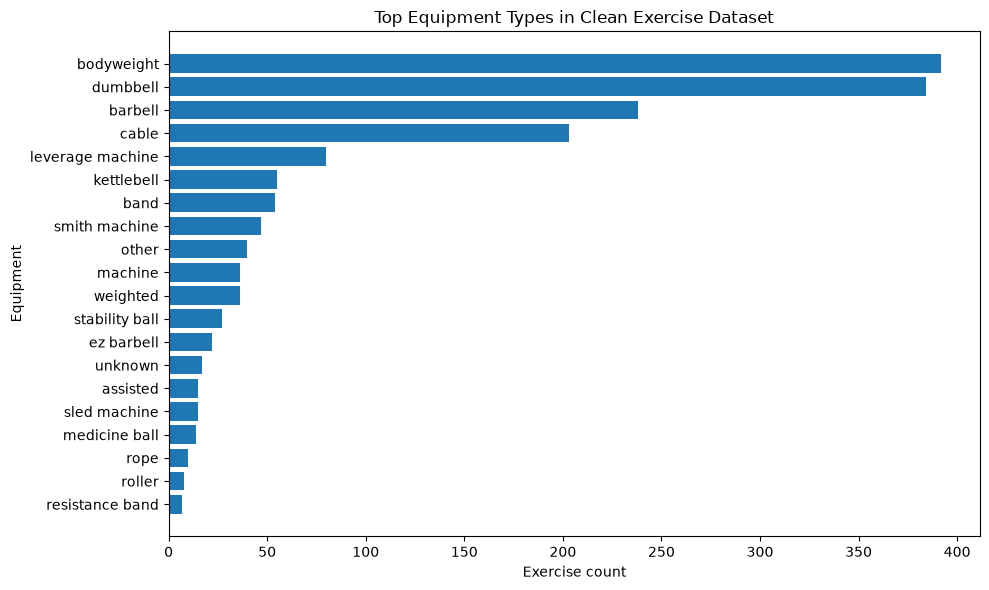

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\exercise_cleaning_equipment.png


In [9]:
equipment_counts = cleaned_df["equipment"].value_counts().head(20)

plt.figure(figsize=(10, 6))
plt.barh(equipment_counts.index[::-1], equipment_counts.values[::-1])
plt.title("Top Equipment Types in Clean Exercise Dataset")
plt.xlabel("Exercise count")
plt.ylabel("Equipment")
plt.tight_layout()

output_path = FIGURES_DIR / "exercise_cleaning_equipment.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## 10. Chart exercise count by target muscle

This chart shows the most common target muscles in the cleaned dataset.

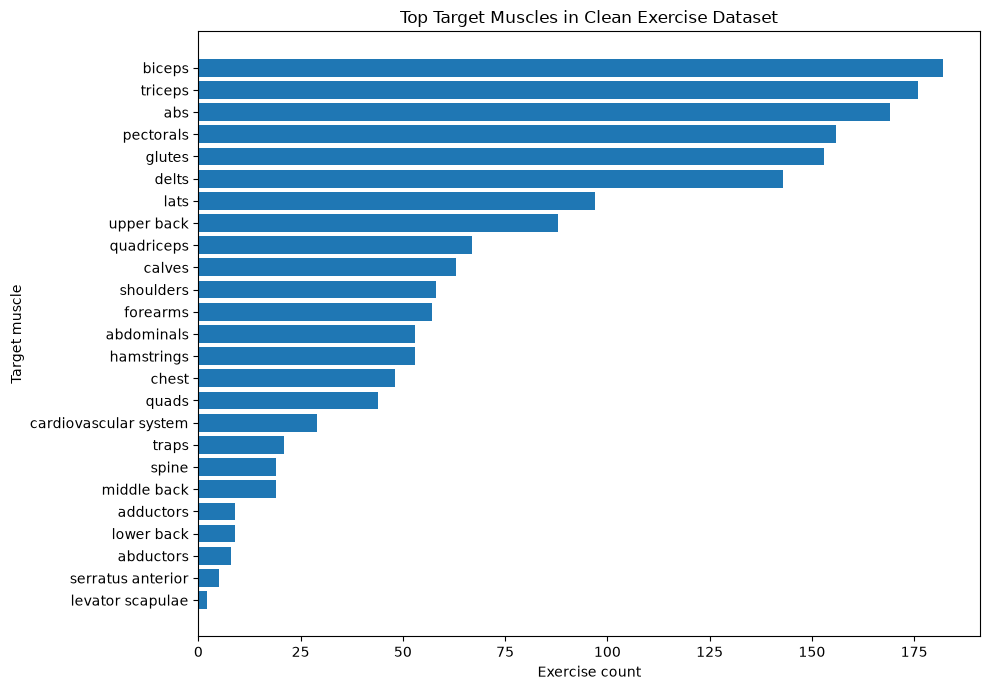

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\exercise_cleaning_target_muscles.png


In [10]:
target_counts = cleaned_df["target_muscle"].value_counts().head(25)

plt.figure(figsize=(10, 7))
plt.barh(target_counts.index[::-1], target_counts.values[::-1])
plt.title("Top Target Muscles in Clean Exercise Dataset")
plt.xlabel("Exercise count")
plt.ylabel("Target muscle")
plt.tight_layout()

output_path = FIGURES_DIR / "exercise_cleaning_target_muscles.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## 11. Check duplicates

This cell checks whether duplicate exercise identities still exist after cleaning.

The dedupe key uses:

- name
- target muscle
- equipment

In [11]:
duplicate_check_df = cleaned_df.copy()

duplicate_check_df["dedupe_key"] = (
    duplicate_check_df["name"].str.lower().str.strip()
    + "|"
    + duplicate_check_df["target_muscle"].str.lower().str.strip()
    + "|"
    + duplicate_check_df["equipment"].str.lower().str.strip()
)

duplicate_count = int(duplicate_check_df.duplicated(subset=["dedupe_key"]).sum())

print("Remaining duplicate count:", duplicate_count)

if duplicate_count > 0:
    display(duplicate_check_df[duplicate_check_df.duplicated(subset=["dedupe_key"], keep=False)].head(20))

Remaining duplicate count: 0


## 12. Save final review tables

This cell saves quick review files for tracking and documentation.

In [12]:
cleaned_preview_path = REPORTS_DIR / "exercise_cleaned_preview.csv"
unknown_summary_path = REPORTS_DIR / "exercise_unknown_summary.csv"

cleaned_df.head(100).to_csv(cleaned_preview_path, index=False)
unknown_df.to_csv(unknown_summary_path, index=False)

print("Saved:", cleaned_preview_path)
print("Saved:", unknown_summary_path)

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\exercise_cleaned_preview.csv
Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\exercise_unknown_summary.csv


## 13. Final cleaning decision

Use this section to write the final human decision after reviewing the charts and tables.

Questions:

1. Is the cleaned dataset suitable for the MVP exercise library?
2. Are body part and muscle categories clean enough?
3. Is equipment data usable?
4. Are too many instructions missing?
5. Should we improve normalization rules before exporting to JSON?

## 14. Validate cleaned dataset

This cell runs the reusable validation script.

Validation checks:

- Required columns exist
- Exercise IDs are unique
- Exercise identity duplicates are removed
- Unknown rates are acceptable
- Exercise type values are allowed

In [13]:
from scripts.validate_clean_data import run_validation

validation_df = run_validation()
display(validation_df)

                                check  passed                          details
0         required_column_exercise_id    True                    Column exists
1                required_column_name    True                    Column exists
2           required_column_body_part    True                    Column exists
3       required_column_target_muscle    True                    Column exists
4   required_column_secondary_muscles    True                    Column exists
5           required_column_equipment    True                    Column exists
6       required_column_exercise_type    True                    Column exists
7    required_column_difficulty_level    True                    Column exists
8        required_column_instructions    True                    Column exists
9      required_column_source_dataset    True                    Column exists
10                 unique_exercise_id    True   Duplicate exercise_id count: 0
11       unique_name_target_equipment    True      D

,check,passed,details
0,required_column_exercise_id,True,Column exists
1,required_column_name,True,Column exists
2,required_column_body_part,True,Column exists
3,required_column_target_muscle,True,Column exists
4,required_column_secondary_muscles,True,Column exists
5,required_column_equipment,True,Column exists
6,required_column_exercise_type,True,Column exists
7,required_column_difficulty_level,True,Column exists
8,required_column_instructions,True,Column exists
9,required_column_source_dataset,True,Column exists
